# Text-to-Brain & Brain-to-Text Evaluation

This notebook quantitatively evaluates NeuroVLM's two generative directions:

| Direction | What is evaluated | Metrics |
|---|---|---|
| **Brain → Text** | Quality of LLM-generated descriptions compared to reference labels | BLEU, ROUGE-1, ROUGE-2, ROUGE-L |
| **Text → Brain** | Fidelity of predicted activation maps vs. ground-truth brain maps | Pearson *r*, PSNR, SSIM, Dice |

**Prerequisites**
```bash
pip install neurovlm[metrics,llm,viz]

# For brain-to-text generation, one of:
ollama pull qwen2.5:3b-instruct   # fast, needs Ollama running
# or the HuggingFace path (no server) is used automatically when ollama= is set to huggingface
```

In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from sklearn.metrics import auc

from neurovlm import NeuroVLM
from neurovlm.data import load_latent, load_masker
from neurovlm.metrics import (
    bleu,
    rouge,
    pearson_correlation,
    psnr,
    compute_metrics,
    recall_curve,
)

nvlm = NeuroVLM()
masker = load_masker()

## 1. Load Reference Brain Networks

We use the Du et al. ICA atlas as ground-truth brain maps. Each network has a
well-known cognitive label we treat as the reference text for BLEU/ROUGE.

In [2]:
networks = load_latent("networks_neuro")
du = networks["Du"]

# Select representative networks with clear cognitive labels
# Available Du keys: VIS-P, CG-OP, DN-B, SMOT-B, AUD, PM-PPr, dATN-B,
#                     SMOT-A, LANG, FPN-B, FPN-A, dATN-A, VIS-C, SAL/PMN, DN-A, NONE
NETWORKS = {
    "AUD":    (du["AUD"],     "auditory processing"),
    "VIS-P":  (du["VIS-P"],   "primary visual cortex visual processing"),
    "SMOT-A": (du["SMOT-A"],  "sensorimotor cortex motor execution"),
    "DN-A":   (du["DN-A"],    "default mode network self-referential processing"),
    "FPN-A":  (du["FPN-A"],   "frontoparietal network executive control working memory"),
    "LANG":   (du["LANG"],    "language processing speech comprehension"),
}

print(f"Loaded {len(NETWORKS)} networks: {', '.join(NETWORKS.keys())}")


Loaded 6 networks: AUD, VIS-P, SMOT-A, DN-A, FPN-A, LANG


## 2. Brain-to-Text Evaluation (BLEU & ROUGE)

For each network we:
1. Run `brain().to_text()` to retrieve the most similar publications / concepts.
2. Pass those to `generate_llm_response()` to get a free-form description.
3. Score the description against the network's known cognitive label.

> **Note:** Change `LLM_BACKEND` to `"huggingface"` and set `LLM_MODEL` to
> `"Qwen/Qwen2.5-1.5B-Instruct"` if Ollama is not available.

In [3]:
LLM_BACKEND = "ollama"          # "ollama" or "huggingface"
LLM_MODEL   = "qwen2.5:3b-instruct"  # change to e.g. "Qwen/Qwen2.5-1.5B-Instruct" for HF

In [5]:
b2t_records = []

for name, (latent, reference_label) in NETWORKS.items():
    print(f"\n--- {name} ---")

    # Step 1: contrastive retrieval
    result = nvlm.brain(latent).to_text()

    # Filter to NeuroWiki (wiki) and Cognitive Atlas (cogatlas) only
    wiki_table     = result.top_k(5, dataset="wiki").query("cosine_similarity > 0.4")
    cogatlas_table = result.top_k(5, dataset="cogatlas").query("cosine_similarity > 0.4")
    context_table  = pd.concat([wiki_table, cogatlas_table], ignore_index=True)

    if context_table.empty:
        print("  No high-confidence matches — skipping LLM.")
        continue

    print(f"  wiki: {len(wiki_table)} rows, cogatlas: {len(cogatlas_table)} rows")

    # Step 2: LLM generation
    generated = nvlm.generate_llm_response(
        backend=LLM_BACKEND,
        model_name=LLM_MODEL,
        table=context_table,
        max_new_tokens=256,
        verbose=False,
    )
    print(f"  Generated ({len(generated.split())} words): {generated[:120]}...")

    # Step 3: compute BLEU and ROUGE against the reference label
    bleu_score   = bleu([reference_label], generated, n=4)
    rouge_scores = rouge(reference_label, generated)

    b2t_records.append({
        "network":    name,
        "reference":  reference_label,
        "generated":  generated,
        "wiki_rows":  len(wiki_table),
        "cog_rows":   len(cogatlas_table),
        "bleu":       bleu_score,
        "rouge1_f":   rouge_scores["rouge1"]["fmeasure"],
        "rouge2_f":   rouge_scores["rouge2"]["fmeasure"],
        "rougeL_f":   rouge_scores["rougeL"]["fmeasure"],
        "rouge1_p":   rouge_scores["rouge1"]["precision"],
        "rouge1_r":   rouge_scores["rouge1"]["recall"],
    })

b2t_df = pd.DataFrame(b2t_records).set_index("network")
b2t_df[["wiki_rows", "cog_rows", "bleu", "rouge1_f", "rouge2_f", "rougeL_f"]].round(3)



--- AUD ---
  wiki: 5 rows, cogatlas: 5 rows
  Generated (429 words): The provided brain activation pattern is associated with processes related to temporal masking and beat perception. This...

--- VIS-P ---
  No high-confidence matches — skipping LLM.

--- SMOT-A ---
  wiki: 5 rows, cogatlas: 1 rows
  Generated (269 words): The provided brain activation pattern is associated with a large-scale sensorimotor network (SMN), which includes the so...

--- DN-A ---
  wiki: 5 rows, cogatlas: 0 rows
  Generated (335 words): Based on the provided neuroscience concepts from NeuroWiki and Cognitive Atlas terms, the brain activation pattern appea...

--- FPN-A ---
  No high-confidence matches — skipping LLM.

--- LANG ---
  wiki: 5 rows, cogatlas: 0 rows
  Generated (279 words): The brain activation pattern associated with these concepts represents a complex interplay between cognitive processes r...


,wiki_rows,cog_rows,bleu,rouge1_f,rouge2_f,rougeL_f
network,,,,,,
AUD,5,5,0.000,0.009,0.005,0.009
SMOT-A,5,1,0.001,0.029,0.000,0.022
DN-A,5,0,0.003,0.034,0.017,0.034
LANG,5,0,0.001,0.021,0.000,0.014


### 2.1 Plot Brain-to-Text Scores

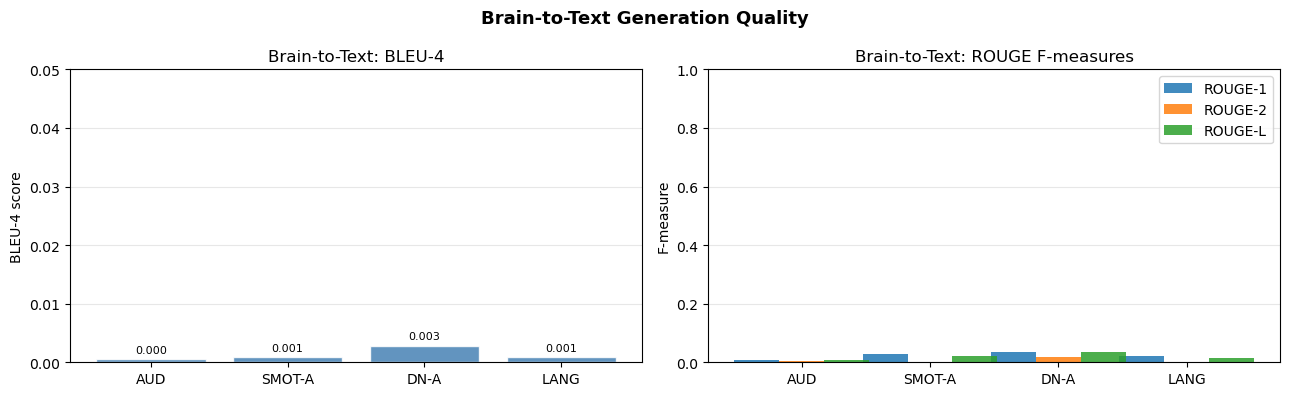

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

nets = b2t_df.index.tolist()
x = np.arange(len(nets))
w = 0.35

# Left: BLEU
ax = axes[0]
bars = ax.bar(x, b2t_df["bleu"], color="steelblue", alpha=0.85, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(nets)
ax.set_ylabel("BLEU-4 score")
ax.set_title("Brain-to-Text: BLEU-4")
ax.set_ylim(0, max(b2t_df["bleu"].max() * 1.35, 0.05))
ax.grid(axis="y", alpha=0.3)

# Right: ROUGE F-measures
ax = axes[1]
ax.bar(x - w, b2t_df["rouge1_f"], w, label="ROUGE-1", color="C0", alpha=0.85)
ax.bar(x,     b2t_df["rouge2_f"], w, label="ROUGE-2", color="C1", alpha=0.85)
ax.bar(x + w, b2t_df["rougeL_f"], w, label="ROUGE-L", color="C2", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(nets)
ax.set_ylabel("F-measure")
ax.set_title("Brain-to-Text: ROUGE F-measures")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

fig.suptitle("Brain-to-Text Generation Quality", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("brain_to_text_scores.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 ROUGE Precision vs Recall

Precision measures how much of the generated text appears in the reference;
Recall measures how much of the reference is covered by the generated text.

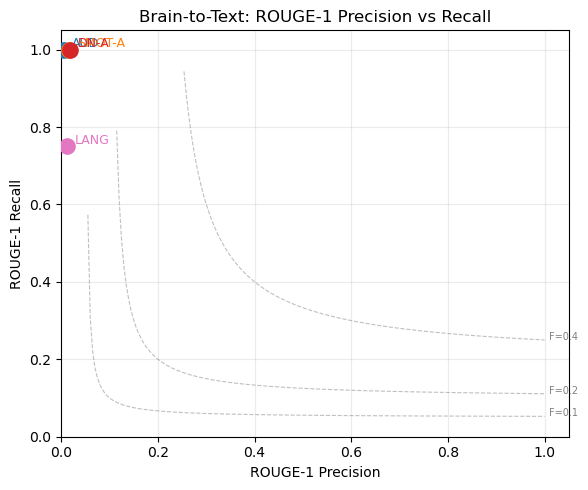

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

colors = plt.cm.tab10(np.linspace(0, 0.6, len(b2t_df)))
for (net, row), c in zip(b2t_df.iterrows(), colors):
    ax.scatter(row["rouge1_p"], row["rouge1_r"], s=120, color=c, zorder=3)
    ax.annotate(net, (row["rouge1_p"], row["rouge1_r"]),
                textcoords="offset points", xytext=(6, 2), fontsize=9, color=c)

# F=0.2, 0.4, 0.6 iso-curves
p_range = np.linspace(0.01, 1.0, 200)
for f in [0.1, 0.2, 0.4]:
    r_iso = f * p_range / (2 * p_range - f + 1e-9)
    mask = (r_iso >= 0) & (r_iso <= 1)
    ax.plot(p_range[mask], r_iso[mask], "--", lw=0.8, color="grey", alpha=0.5)
    ax.text(p_range[mask][-1] + 0.01, r_iso[mask][-1], f"F={f}", fontsize=7, color="grey")

ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.set_xlabel("ROUGE-1 Precision")
ax.set_ylabel("ROUGE-1 Recall")
ax.set_title("Brain-to-Text: ROUGE-1 Precision vs Recall")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.savefig("brain_to_text_rouge_pr.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Text-to-Brain Evaluation (Pearson *r*, PSNR, SSIM, Dice)

We generate a brain activation map from each network's cognitive label and
compare it against the reference network map.

The ground-truth map for each network is obtained by decoding its pre-encoded
latent vector through the autoencoder — this is the model's own internal
representation of the real brain image.

In [8]:
from neurovlm.train import which_device

device = which_device()
print(f"Device: {device}")


Device: mps


In [9]:
t2b_records = []

for name, (latent, label) in NETWORKS.items():
    print(f"Processing {name}...")

    # --- Generated brain map (uses the result's internal decoder — device-safe) ---
    gen_result = nvlm.text(label).to_brain(head="mse")
    nifti_pred = gen_result.to_nifti(index=0)
    brain_pred = masker.transform(nifti_pred).ravel().astype("float32")

    # --- Ground-truth map: decode the real latent via the same attached decoder ---
    with torch.no_grad():
        dec = gen_result.decoder
        dec_device = next(dec.parameters()).device
        brain_true = (
            torch.sigmoid(dec(latent.unsqueeze(0).to(dec_device)))
            .squeeze(0).cpu().numpy()
        )

    # --- Scalar similarity metrics ---
    r = pearson_correlation(brain_true, brain_pred)
    p = psnr(brain_true, brain_pred, data_range=1.0)
    mse_t, ssim_t, dice_t = compute_metrics(
        torch.from_numpy(brain_true),
        torch.from_numpy(brain_pred),
        thresholds=(0.25, 0.5), percentile=False
    )

    t2b_records.append({
        "network": name,
        "label": label,
        "pearson_r": r,
        "psnr_db": p,
        "ssim_t025": ssim_t[0],
        "ssim_t050": ssim_t[1],
        "dice_t025": dice_t[0],
        "dice_t050": dice_t[1],
        "mse_t025": mse_t[0],
        "mse_t050": mse_t[1],
        "brain_true": brain_true,
        "brain_pred": brain_pred,
    })

t2b_df = pd.DataFrame(t2b_records).set_index("network")
display_cols = ["pearson_r", "psnr_db", "ssim_t025", "ssim_t050", "dice_t025", "dice_t050"]
t2b_df[display_cols].round(3)


Processing AUD...


Processing VIS-P...
Processing SMOT-A...
Processing DN-A...
Processing FPN-A...
Processing LANG...


,pearson_r,psnr_db,ssim_t025,ssim_t050,dice_t025,dice_t050
network,,,,,,
AUD,0.635,22.426,0.940,0.975,0.488,0.404
VIS-P,0.109,17.382,0.875,0.947,0.010,0.000
SMOT-A,0.564,19.998,0.900,0.951,0.488,0.207
DN-A,0.449,21.397,0.927,0.959,0.194,0.000
FPN-A,0.541,22.545,0.920,0.965,0.071,0.000
LANG,0.543,20.206,0.903,0.946,0.340,0.125


### 3.1 Overview: All Text-to-Brain Metrics

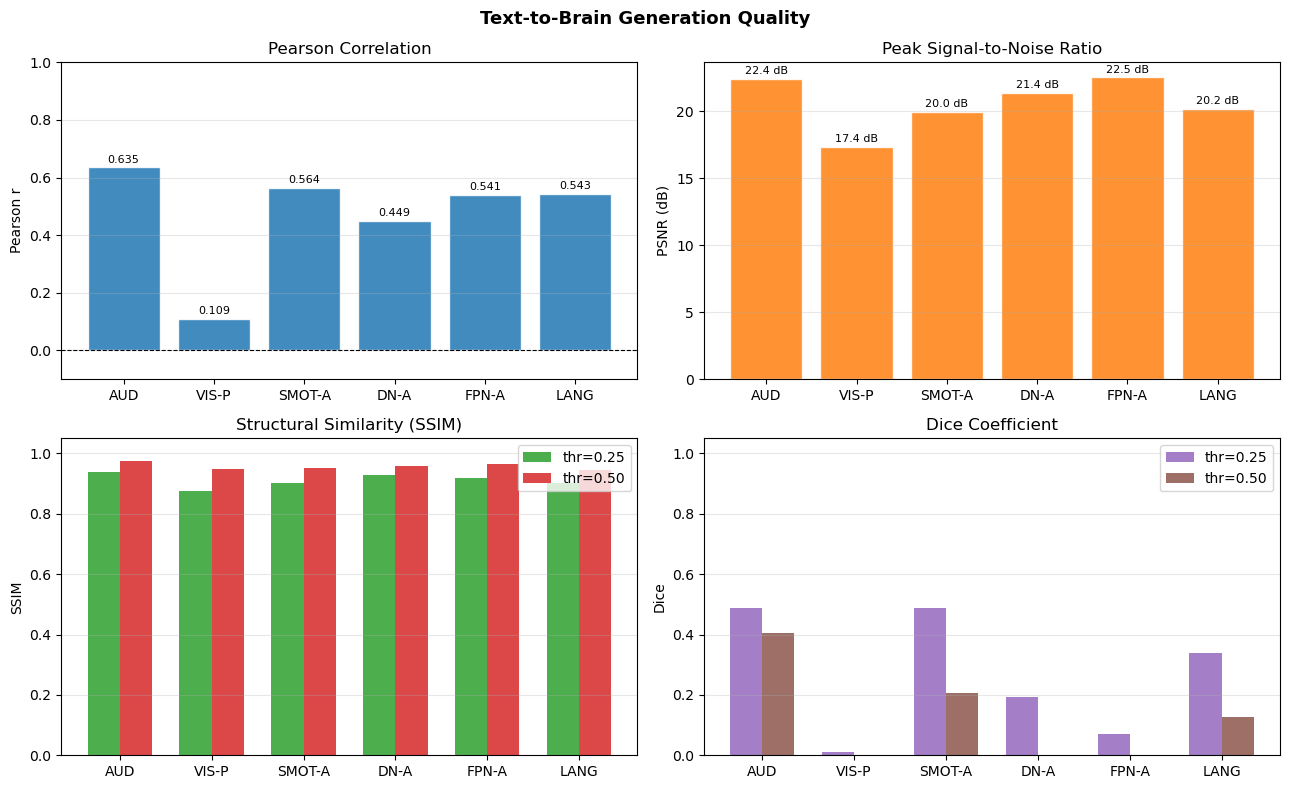

In [10]:
nets = t2b_df.index.tolist()
x = np.arange(len(nets))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Pearson r
ax = axes[0, 0]
bars = ax.bar(x, t2b_df["pearson_r"], color="C0", alpha=0.85, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xticks(x); ax.set_xticklabels(nets)
ax.set_ylabel("Pearson r")
ax.set_title("Pearson Correlation")
ax.set_ylim(-0.1, 1.0)
ax.grid(axis="y", alpha=0.3)

# PSNR
ax = axes[0, 1]
bars = ax.bar(x, t2b_df["psnr_db"], color="C1", alpha=0.85, edgecolor="white")
ax.bar_label(bars, fmt="%.1f dB", padding=2, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(nets)
ax.set_ylabel("PSNR (dB)")
ax.set_title("Peak Signal-to-Noise Ratio")
ax.grid(axis="y", alpha=0.3)

# SSIM at two thresholds
ax = axes[1, 0]
w = 0.35
ax.bar(x - w/2, t2b_df["ssim_t025"], w, label="thr=0.25", color="C2", alpha=0.85)
ax.bar(x + w/2, t2b_df["ssim_t050"], w, label="thr=0.50", color="C3", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(nets)
ax.set_ylabel("SSIM")
ax.set_title("Structural Similarity (SSIM)")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Dice at two thresholds
ax = axes[1, 1]
ax.bar(x - w/2, t2b_df["dice_t025"], w, label="thr=0.25", color="C4", alpha=0.85)
ax.bar(x + w/2, t2b_df["dice_t050"], w, label="thr=0.50", color="C5", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(nets)
ax.set_ylabel("Dice")
ax.set_title("Dice Coefficient")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.suptitle("Text-to-Brain Generation Quality", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("text_to_brain_scores.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2 Pearson *r* vs PSNR Scatter

Points in the upper-right represent networks where text-to-brain generation is most faithful.

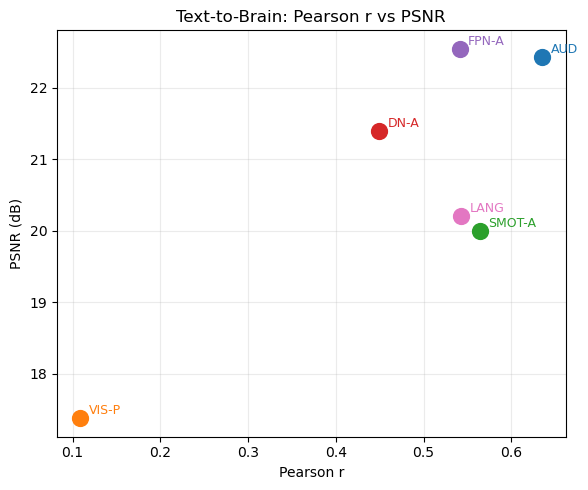

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

colors = plt.cm.tab10(np.linspace(0, 0.6, len(t2b_df)))
for (net, row), c in zip(t2b_df.iterrows(), colors):
    ax.scatter(row["pearson_r"], row["psnr_db"], s=130, color=c, zorder=3)
    ax.annotate(net, (row["pearson_r"], row["psnr_db"]),
                textcoords="offset points", xytext=(6, 3), fontsize=9, color=c)

ax.set_xlabel("Pearson r")
ax.set_ylabel("PSNR (dB)")
ax.set_title("Text-to-Brain: Pearson r vs PSNR")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.savefig("text_to_brain_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3 Generated vs Reference Brain Maps

Visual comparison of the predicted (text→brain) activation map against the
reference network map, rendered on the MNI152 surface.

/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_91027/115258803.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


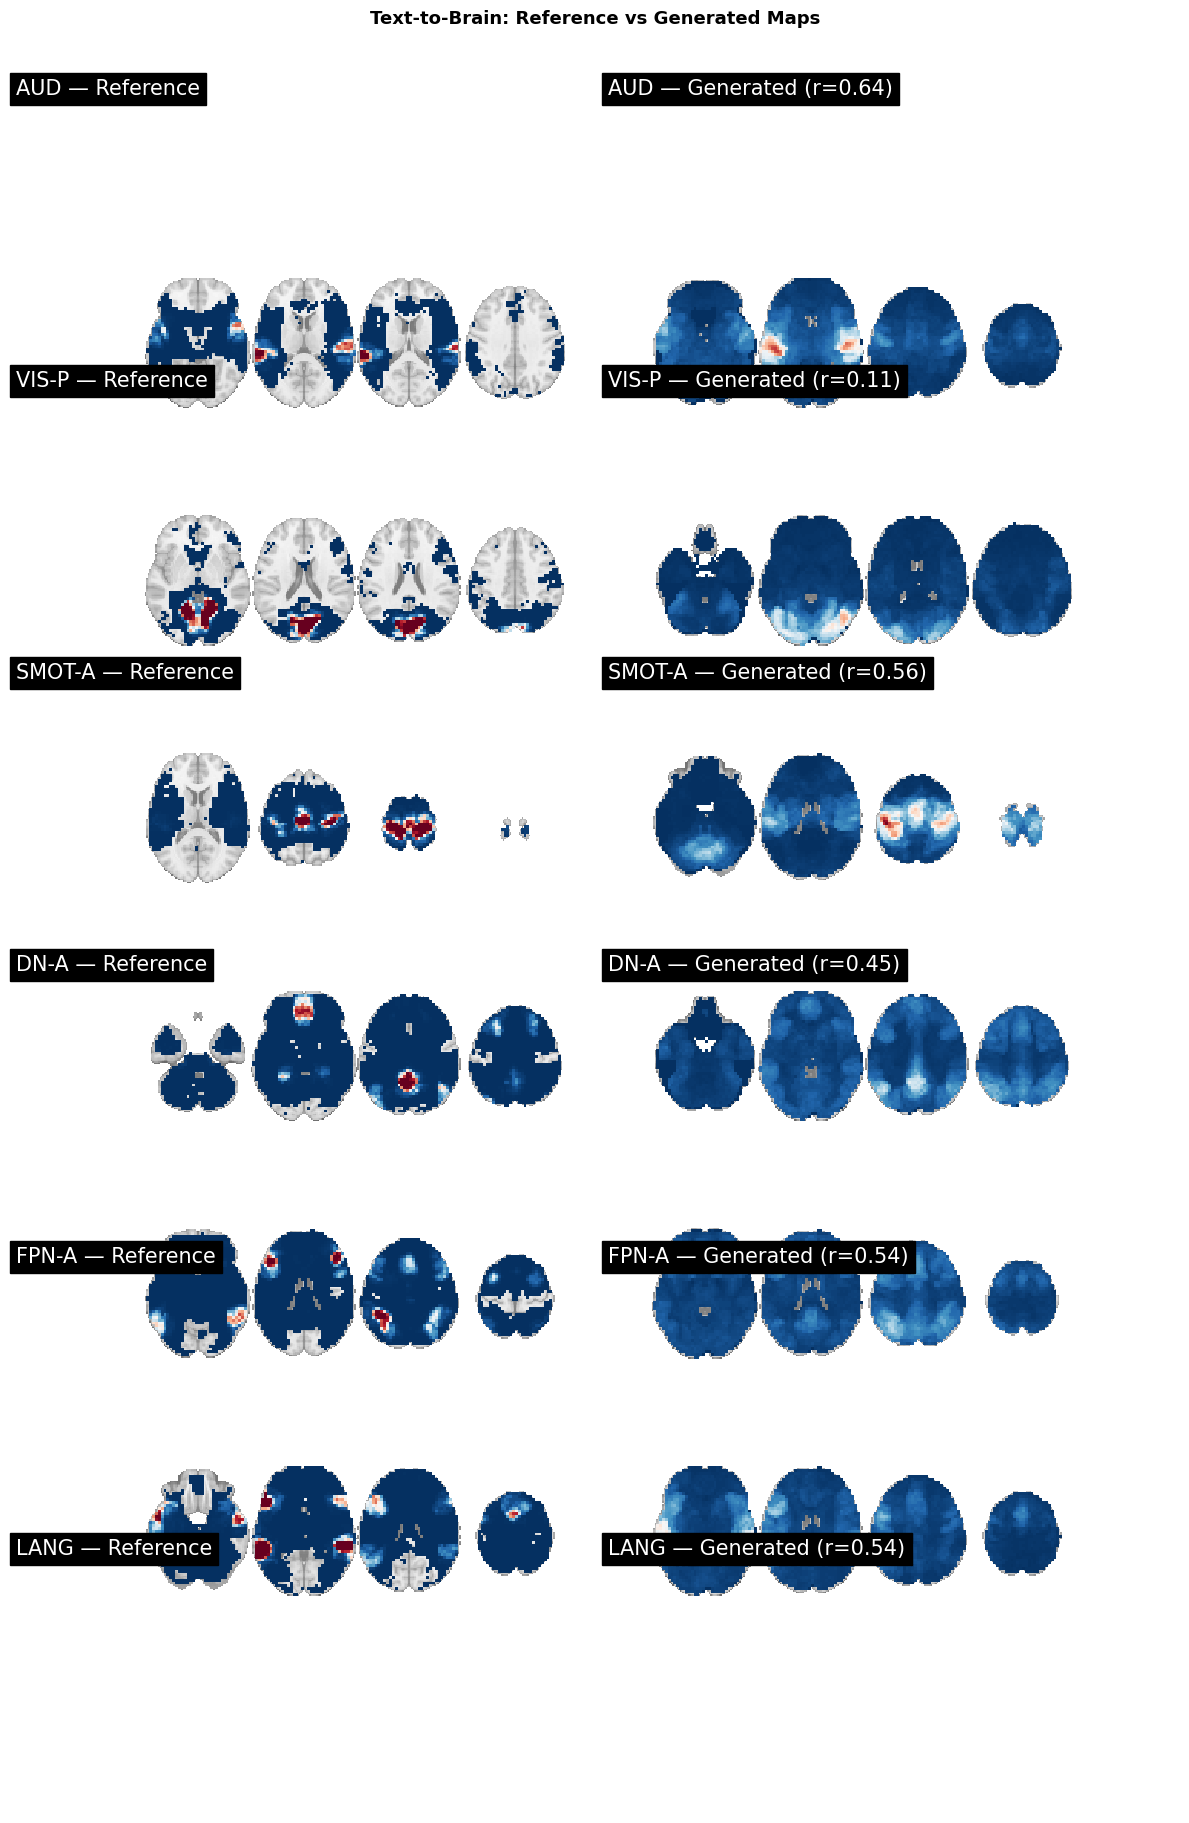

In [12]:
from nilearn import plotting as niplot
from nilearn.datasets import load_mni152_template

bg = load_mni152_template(resolution=2)
n_nets = len(t2b_df)

fig, axes = plt.subplots(n_nets, 2, figsize=(12, 3 * n_nets))

for row_idx, (net, row) in enumerate(t2b_df.iterrows()):
    nifti_true = masker.inverse_transform(row["brain_true"].reshape(1, -1))
    nifti_pred = masker.inverse_transform(row["brain_pred"].reshape(1, -1))

    for col_idx, (img, subtitle) in enumerate([
        (nifti_true, f"{net} — Reference"),
        (nifti_pred, f"{net} — Generated (r={row['pearson_r']:.2f})"),
    ]):
        ax = axes[row_idx, col_idx]
        niplot.plot_stat_map(
            img,
            bg_img=bg,
            display_mode="z",
            cut_coords=4,
            colorbar=False,
            title=subtitle,
            axes=ax,
            black_bg=False,
            draw_cross=False,
            annotate=False,
            vmax=0.8,
        )

fig.suptitle("Text-to-Brain: Reference vs Generated Maps", fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig("text_to_brain_maps.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Contrastive Alignment: Recall Curves

The recall@K curves assess whether the generated representation of a brain
map (or text) can be matched back to its correct counterpart using cosine
similarity in the shared latent space.

- **Text-to-Brain (T→B)**: rank all reference brain latents by similarity to the text-generated latent; what fraction contain the correct network within the top-K?
- **Brain-to-Text (B→T)**: the same query in reverse.

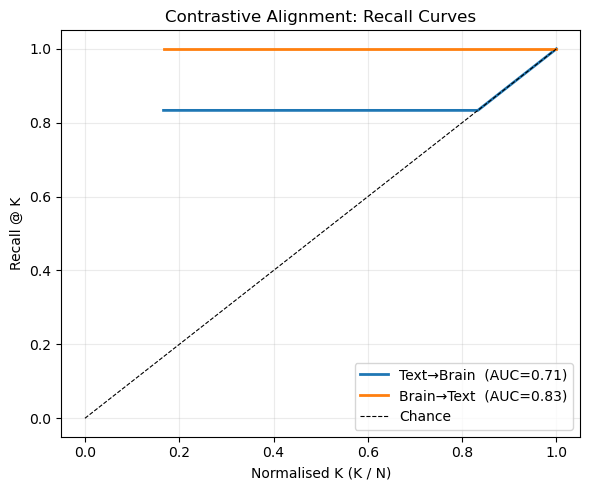

In [13]:
from neurovlm.models import load_model
import torch.nn.functional as F

proj_head_img  = load_model("proj_head_image_infonce").to(device)
proj_head_text = load_model("proj_head_text_infonce").to(device)

# Stack true and predicted latents
true_latents = torch.stack([latent for latent, _ in NETWORKS.values()]).to(device)
pred_latents = torch.stack([gen_result.latents[0] for gen_result in [
    nvlm.text(label).to_brain(head="mse") for _, (_, label) in NETWORKS.items()
]]).to(device)

with torch.no_grad():
    z_true = F.normalize(proj_head_img(true_latents), dim=1).cpu()
    z_pred = F.normalize(proj_head_img(pred_latents), dim=1).cpu()

t_to_b, b_to_t = recall_curve(z_pred, z_true, step=1)

n = len(t_to_b)
ks = np.arange(1, n + 1) / n

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(ks, t_to_b.numpy(), color="C0", lw=2, label=f"Text→Brain  (AUC={auc(ks, t_to_b.numpy()):.2f})")
ax.plot(ks, b_to_t.numpy(), color="C1", lw=2, label=f"Brain→Text  (AUC={auc(ks, b_to_t.numpy()):.2f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Chance")
ax.set_xlabel("Normalised K (K / N)")
ax.set_ylabel("Recall @ K")
ax.set_title("Contrastive Alignment: Recall Curves")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.savefig("recall_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Summary Table

In [14]:
# Merge brain-to-text and text-to-brain summaries
summary = pd.concat([
    b2t_df[["bleu", "rouge1_f", "rouge2_f", "rougeL_f"]].rename(
        columns={"bleu": "BLEU-4", "rouge1_f": "R1-F", "rouge2_f": "R2-F", "rougeL_f": "RL-F"}
    ),
    t2b_df[["pearson_r", "psnr_db", "ssim_t025", "dice_t025"]].rename(
        columns={
            "pearson_r": "Pearson r",
            "psnr_db": "PSNR (dB)",
            "ssim_t025": "SSIM (0.25)",
            "dice_t025": "Dice (0.25)",
        }
    ),
], axis=1)

print("\n=== Evaluation Summary ===")
print(summary.round(3).to_string())
print(f"\nMean BLEU-4:     {summary['BLEU-4'].mean():.3f}")
print(f"Mean ROUGE-1 F:  {summary['R1-F'].mean():.3f}")
print(f"Mean Pearson r:  {summary['Pearson r'].mean():.3f}")
print(f"Mean PSNR:       {summary['PSNR (dB)'].mean():.1f} dB")
print(f"Mean SSIM:       {summary['SSIM (0.25)'].mean():.3f}")
print(f"Mean Dice:       {summary['Dice (0.25)'].mean():.3f}")


=== Evaluation Summary ===
         BLEU-4   R1-F   R2-F   RL-F  Pearson r  PSNR (dB)  SSIM (0.25)  Dice (0.25)
network                                                                             
AUD       0.000  0.009  0.005  0.009      0.635     22.426        0.940        0.488
SMOT-A    0.001  0.029  0.000  0.022      0.564     19.998        0.900        0.488
DN-A      0.003  0.034  0.017  0.034      0.449     21.397        0.927        0.194
LANG      0.001  0.021  0.000  0.014      0.543     20.206        0.903        0.340
VIS-P       NaN    NaN    NaN    NaN      0.109     17.382        0.875        0.010
FPN-A       NaN    NaN    NaN    NaN      0.541     22.545        0.920        0.071

Mean BLEU-4:     0.001
Mean ROUGE-1 F:  0.023
Mean Pearson r:  0.474
Mean PSNR:       20.7 dB
Mean SSIM:       0.911
Mean Dice:       0.265


### 5.1 Radar / Spider Chart — Per-Network Profile

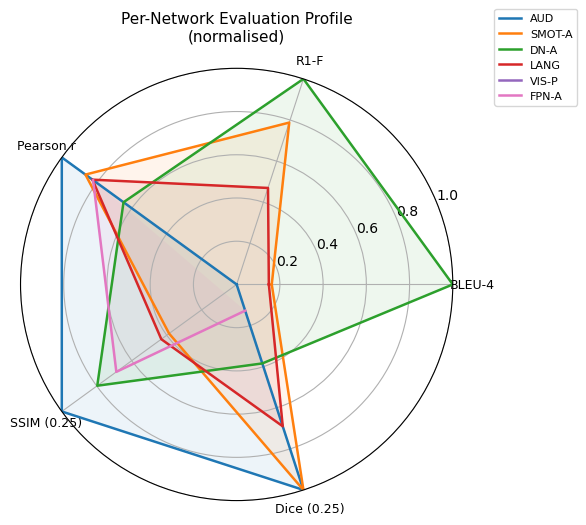

In [15]:
radar_metrics = ["BLEU-4", "R1-F", "Pearson r", "SSIM (0.25)", "Dice (0.25)"]
radar_df = summary[radar_metrics].copy()

# Normalise each column to [0, 1] for comparability
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

colors = plt.cm.tab10(np.linspace(0, 0.6, len(radar_norm)))
for (net, vals), c in zip(radar_norm.iterrows(), colors):
    values = vals.tolist() + vals.tolist()[:1]
    ax.plot(angles, values, lw=1.8, color=c, label=net)
    ax.fill(angles, values, alpha=0.08, color=c)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title("Per-Network Evaluation Profile\n(normalised)", fontsize=11, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15), fontsize=8)
fig.tight_layout()
plt.savefig("radar_profile.png", dpi=150, bbox_inches="tight")
plt.show()